<h1>Experiment: Time perception and Mental States during Musical Improvisation</h1>

<p>This nb explores and analyses a dataset related to an experiment where participants improvised under different tasks in a 2 x 3 design: 

Musical setting: solo vs group
Improvisation Type: Familiar harmony; Unfamiliar Harmony; free(no defined harmonic structure)

Self-reports collected: 

- Duration estimates and how fast time passed
- mental states: fluctuations in attentional demand and focus
- subjective ratings: enjoyment, difficulty, familiarity

Along this nb we will clean and simplify the data set, and then explore relationships among collected measures, mostly focusing on what factors might predict temporal judgements (duration and speed of time passage). 

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np
from sklearn.linear_model import LinearRegression

from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from scipy.stats import shapiro
from scipy.stats import mannwhitneyu

#for mixed models and anovas
import statsmodels.api as sm
import statsmodels.formula.api as smf
import pingouin as pg

#for MIR
import os
import essentia.standard as es


In [7]:
# load file and check

file_path = 'improv-time results base.csv'
df = pd.read_csv(file_path, sep=";" )

df.head(5)

,id. ID da resposta,data_collection,submitdate. Data de submissão,seed. Semente,startdate. Data de início,datestamp. Data da última acção,ID de participante,Tipo de instrumento,G01Q06. Escolha o ID da sessão,Assigned_group,...,engagementEmotional[boring/interesting],engagementAttention[distracted/focused],familiarity[unfamiliar/familiar],focoMusica[SQ001]. Estive focado na performance musical.,focoSala[SQ001]. A minha atenção desviou-se para elementos da sala que não tinham relação com a performance musical.,focoPensExter[SQ001]. A minha atenção desviou-se para pensamentos não diretamente relacionados com a performance musical.,Branco[SQ001]. Houve momentos em que a minha mente estava “em branco” ou sem qualquer tipo de pensamento ativo.,SecundarioMusica[SQ001]. Tive pensamentos ou preocupações relacionadas com aspetos secundários e interferentes da performance musical.,Probe2. Indique. por favor. qual dos seguintes estados mentais foi mais predominante neste take:,Formato audio
0,3.0,PJ,2025-02-03 16:39:35,700985127,2025-02-03 16:33:35,2025-02-03 16:39:35,LA06H,Harmonic,Grupo - B - Não familiar,Group0,...,3.5,4.0,4.5,4.5,1.0,1.5,2.0,3.0,Estive focado na performance musical.,.mp3
1,4.0,PJ,2025-02-03 16:38:37,1847374883,2025-02-03 16:33:38,2025-02-03 16:38:37,oa03B,Bass,Grupo - B - Não familiar,Group0,...,2.0,4.5,4.5,4.0,1.0,1.7,3.0,1.5,Estive focado na performance musical.,.mp3
2,5.0,PJ,2025-02-03 16:39:51,986712179,2025-02-03 16:33:40,2025-02-03 16:39:51,oa07D,Drum,Grupo - B - Não familiar,Group0,...,4.0,3.5,4.0,4.5,1.0,1.0,5.0,1.0,Estive focado na performance musical.,.mp3
3,6.0,PJ,2025-02-03 16:37:32,564415062,2025-02-03 16:33:56,2025-02-03 16:37:32,OA05M,Melodic,Grupo - B - Não familiar,Group0,...,3.7,3.7,3.8,3.6,1.6,1.7,1.8,2.2,Estive focado na performance musical.,.mp3
4,34.0,PJ,2025-02-04 13:07:16,1648400236,2025-02-04 13:04:30,2025-02-04 13:07:16,ea09D,Drum,Grupo - B - Não familiar,Group1,...,3.8,5.0,4.0,4.9,1.2,1.3,1.0,1.1,Estive focado na performance musical.,.mp3


In [8]:
#STEP 1 - data cleaning
# remove irrelevant columns

df = df.drop(["submitdate. Data de submissão", "seed. Semente", "startdate. Data de início" , "datestamp. Data da última acção", "id. ID da resposta"], axis=1)


In [9]:
#look for empty cells 
row= df.shape[0]
missing_data = df.isnull()
for column in missing_data:
    for i in range(0, row):
        if missing_data[column][i] == True:
            print(column)
            print(missing_data[column].value_counts())
            break


In [10]:
# if needed, remove missing values and confirm again
df = df.dropna()
missing_data = df.isnull()
for column in missing_data:
    print(missing_data[column].value_counts())


data_collection
False    277
Name: count, dtype: int64
ID de participante
False    277
Name: count, dtype: int64
Tipo de instrumento 
False    277
Name: count, dtype: int64
G01Q06. Escolha o ID da sessão
False    277
Name: count, dtype: int64
Assigned_group
False    277
Name: count, dtype: int64
Group-Solo
False    277
Name: count, dtype: int64
Type-improv
False    277
Name: count, dtype: int64
Real_duration(s)
False    277
Name: count, dtype: int64
Duration_estimate[min.]
False    277
Name: count, dtype: int64
Duration_estimate[sec.]
False    277
Name: count, dtype: int64
PoT[slow/fast]
False    277
Name: count, dtype: int64
difficulty[easy/difficult]
False    277
Name: count, dtype: int64
engagementEmotional[boring/interesting]
False    277
Name: count, dtype: int64
engagementAttention[distracted/focused]
False    277
Name: count, dtype: int64
familiarity[unfamiliar/familiar]
False    277
Name: count, dtype: int64
focoMusica[SQ001]. Estive focado na performance musical.
False    277


In [11]:
#confirm data type
df.dtypes


data_collection                                                                                                                            object
ID de participante                                                                                                                         object
Tipo de instrumento                                                                                                                        object
G01Q06. Escolha o ID da sessão                                                                                                             object
Assigned_group                                                                                                                             object
Group-Solo                                                                                                                                 object
Type-improv                                                                                                                 

In [12]:
#put categorical variables as such to help model. Object dtype may not be enough
df["Group-Solo"] = pd.Categorical(
    df["Group-Solo"],
    categories=["Group", "Solo"]  # reference = "Group"
)

df["Type-improv"] = pd.Categorical(
    df["Type-improv"],
    categories=["C", "A", "B"]  # reference = "Free"
)

In [13]:
# rename column names to reduce visual clutter

df.rename(columns={"focoMusica[SQ001]. Estive focado na performance musical.":"FA"}, inplace=True)
df.rename(columns={"focoSala[SQ001]. A minha atenção desviou-se para elementos da sala que não tinham relação com a performance musical.":"ED"}, inplace=True)
df.rename(columns={"focoPensExter[SQ001]. A minha atenção desviou-se para pensamentos não diretamente relacionados com a performance musical.":"MW"}, inplace=True)
df.rename(columns={"Branco[SQ001]. Houve momentos em que a minha mente estava “em branco” ou sem qualquer tipo de pensamento ativo.":"MB"}, inplace=True)
df.rename(columns={"SecundarioMusica[SQ001]. Tive pensamentos ou preocupações relacionadas com aspetos secundários e interferentes da performance musical.":"TRI"}, inplace=True)

df.describe(include = "all")

,data_collection,ID de participante,Tipo de instrumento,G01Q06. Escolha o ID da sessão,Assigned_group,Group-Solo,Type-improv,Real_duration(s),Duration_estimate[min.],Duration_estimate[sec.],...,engagementEmotional[boring/interesting],engagementAttention[distracted/focused],familiarity[unfamiliar/familiar],FA,ED,MW,MB,TRI,Probe2. Indique. por favor. qual dos seguintes estados mentais foi mais predominante neste take:,Formato audio
count,277,277,277,277,277,277,277,277.000000,277.000000,277.00000,...,277.000000,277.000000,277.000000,277.000000,277.000000,277.000000,277.000000,277.000000,277,277
unique,2,49,4,6,13,2,3,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,3
top,JOBRA,LA06H,Melodic,Solo - A - Familiar,Group0,Solo,C,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Estive focado na performance musical.,.m4a
freq,163,6,106,49,24,145,93,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,191,147
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,148.501805,3.241877,19.33935,...,3.925993,3.769675,3.637906,4.094224,1.791697,2.140794,2.633574,2.411913,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22.638723,1.371018,16.73083,...,0.937374,0.970704,1.162381,0.748261,0.961300,1.055265,1.212970,1.109985,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.000000,0.000000,0.00000,...,1.000000,1.000000,1.000000,1.300000,1.000000,1.000000,1.000000,1.000000,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,130.000000,2.000000,4.00000,...,3.500000,3.200000,3.000000,3.800000,1.000000,1.200000,1.500000,1.400000,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,150.000000,3.000000,15.00000,...,4.000000,3.900000,3.900000,4.100000,1.500000,2.000000,2.400000,2.200000,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,170.000000,4.000000,30.00000,...,4.600000,4.500000,4.500000,4.600000,2.100000,3.000000,3.700000,3.500000,NaN,NaN


In [ ]:
# add age and gender from another questionnaire

df2 = pd.read_csv('improv-time-demographic_public.csv', sep =";")

df["age"] = ""
df["sex"] = ""

for index1, row1 in df.iterrows():
    for index2, row2 in df2.iterrows():
        if df.loc[index1, "ID de participante"] == df2.loc[index2, "ID"]:
            df.loc[index1, "age"] = df2.loc[index2, "Age"]
            df.loc[index1, "sex"] = df2.loc[index2, "Sex"]
        
df.head(10)


,data_collection,ID de participante,Tipo de instrumento,G01Q06. Escolha o ID da sessão,Assigned_group,Group-Solo,Type-improv,Real_duration(s),Duration_estimate[min.],Duration_estimate[sec.],...,familiarity[unfamiliar/familiar],FA,ED,MW,MB,TRI,Probe2. Indique. por favor. qual dos seguintes estados mentais foi mais predominante neste take:,Formato audio,age,sex
0,PJ,LA06H,Harmonic,Grupo - B - Não familiar,Group0,Group,B,130,3,20,...,4.5,4.5,1.0,1.5,2.0,3.0,Estive focado na performance musical.,.mp3,26,Masculino
1,PJ,oa03B,Bass,Grupo - B - Não familiar,Group0,Group,B,130,3,20,...,4.5,4.0,1.0,1.7,3.0,1.5,Estive focado na performance musical.,.mp3,35,Masculino
2,PJ,oa07D,Drum,Grupo - B - Não familiar,Group0,Group,B,130,3,37,...,4.0,4.5,1.0,1.0,5.0,1.0,Estive focado na performance musical.,.mp3,29,Masculino
3,PJ,OA05M,Melodic,Grupo - B - Não familiar,Group0,Group,B,130,2,58,...,3.8,3.6,1.6,1.7,1.8,2.2,Estive focado na performance musical.,.mp3,26,Masculino
4,PJ,ea09D,Drum,Grupo - B - Não familiar,Group1,Group,B,170,3,0,...,4.0,4.9,1.2,1.3,1.0,1.1,Estive focado na performance musical.,.mp3,29,Masculino
5,PJ,hh04H,Harmonic,Grupo - B - Não familiar,Group1,Group,B,170,3,0,...,5.0,3.3,1.0,3.4,2.2,1.3,Estive focado na performance musical.,.mp3,27,Masculino
6,PJ,MM04M,Melodic,Grupo - B - Não familiar,Group1,Group,B,170,3,0,...,5.0,4.7,1.5,1.0,1.3,1.5,Estive focado na performance musical.,.mp3,29,Masculino
7,PJ,BB04B,Bass,Grupo - B - Não familiar,Group1,Group,B,170,2,30,...,5.0,5.0,1.0,1.0,1.0,1.0,Estive focado na performance musical.,.mp3,33,Masculino
8,PJ,Oa08H,Harmonic,Grupo - B - Não familiar,Group2,Group,B,150,4,23,...,4.0,4.2,1.0,1.0,4.6,1.0,Estive focado na performance musical.,.mp3,26,Masculino
9,PJ,oa11D,Drum,Grupo - B - Não familiar,Group2,Group,B,150,2,15,...,4.0,4.0,1.4,2.3,3.7,3.6,Estive focado na performance musical.,.mp3,29,Masculino


In [15]:
df.to_csv("improv-time 1 - added age and sex.csv")

In [16]:
# STEP 2 - data preparation + calculate new variables:relative estimates abd absolute error.
# calculate relative estimate in new column
df["relative_estimate"] = (df["Duration_estimate[min.]"] * 60 + df["Duration_estimate[sec.]"]) / df["Real_duration(s)"]
df.head()
#save new csv with this new column for sharing with colleagues
df.to_csv('improv-time 2 - clean_columns_added_relative_estimates.csv')

# calculate absolute error in new column
df["absolute error"] = np.abs(df["relative_estimate"] - 1)

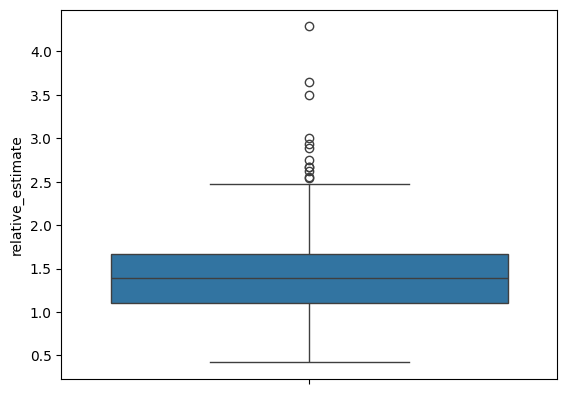

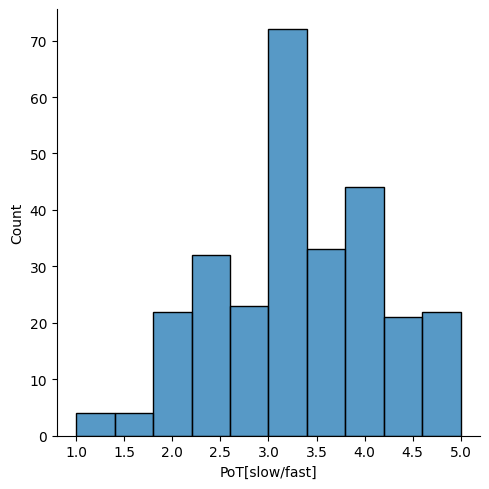

In [17]:
#descriptive statistics to check general distributions, outliers and possible errors, replace variables as needed
sns.boxplot(df["relative_estimate"])

sns.displot(x=df["PoT[slow/fast]"])

In [18]:
df.describe(include = 'all')

,data_collection,ID de participante,Tipo de instrumento,G01Q06. Escolha o ID da sessão,Assigned_group,Group-Solo,Type-improv,Real_duration(s),Duration_estimate[min.],Duration_estimate[sec.],...,ED,MW,MB,TRI,Probe2. Indique. por favor. qual dos seguintes estados mentais foi mais predominante neste take:,Formato audio,age,sex,relative_estimate,absolute error
count,277,277,277,277,277,277,277,277.000000,277.000000,277.00000,...,277.000000,277.000000,277.000000,277.000000,277,277,277.0,277,277.000000,277.000000
unique,2,49,4,6,13,2,3,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,5,3,16.0,4,NaN,NaN
top,JOBRA,LA06H,Melodic,Solo - A - Familiar,Group0,Solo,C,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,Estive focado na performance musical.,.m4a,17.0,Masculino,NaN,NaN
freq,163,6,106,49,24,145,93,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,191,147,65.0,204,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,148.501805,3.241877,19.33935,...,1.791697,2.140794,2.633574,2.411913,NaN,NaN,NaN,NaN,1.446034,0.509100
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22.638723,1.371018,16.73083,...,0.961300,1.055265,1.212970,1.109985,NaN,NaN,NaN,NaN,0.527195,0.466347
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.000000,0.000000,0.00000,...,1.000000,1.000000,1.000000,1.000000,NaN,NaN,NaN,NaN,0.421053,0.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,130.000000,2.000000,4.00000,...,1.000000,1.200000,1.500000,1.400000,NaN,NaN,NaN,NaN,1.100000,0.187500
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,150.000000,3.000000,15.00000,...,1.500000,2.000000,2.400000,2.200000,NaN,NaN,NaN,NaN,1.392857,0.433333
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,170.000000,4.000000,30.00000,...,2.100000,3.000000,3.700000,3.500000,NaN,NaN,NaN,NaN,1.666667,0.666667


In [19]:
"""# compare 2 methods for outliers (for duration estimates). Tested 2 methods and see if they differ. Seem to work equally. Then remove only in DE models later
# 
# --------------- method 1 - above and below 2SD

# first create alternate df to which remove rows from outliers

df_test_outliers2SD = df.copy()
mean_estimate = df_test_outliers2SD["relative_estimate"].mean()
sd2 = 2 * df_test_outliers2SD["relative_estimate"].std()

lower = mean_estimate - sd2
upper = mean_estimate + sd2

df_test_outliers2SD = df_test_outliers2SD[
    (df_test_outliers2SD["relative_estimate"] >= lower) &
    (df_test_outliers2SD["relative_estimate"] <= upper)
]

#check final sample
print("Rows kept: ", len(df_test_outliers2SD))

# -------------- method 2 1.5*IQR


df_test_outliersIQR = df.copy()

q1 = df_test_outliersIQR["relative_estimate"].quantile(0.25)
q3 = df_test_outliersIQR["relative_estimate"].quantile(0.75)
IQR = q3 - q1

lower = q1 - 1.5 * IQR
upper = q3 + 1.5 * IQR

df_test_outliersIQR = df_test_outliersIQR[
    (df_test_outliersIQR["relative_estimate"] >= lower) &
    (df_test_outliersIQR["relative_estimate"] <= upper)
]

print("Rows kept:", len(df_test_outliersIQR))"""

'# compare 2 methods for outliers (for duration estimates). Tested 2 methods and see if they differ. Seem to work equally. Then remove only in DE models later\n# \n# --------------- method 1 - above and below 2SD\n\n# first create alternate df to which remove rows from outliers\n\ndf_test_outliers2SD = df.copy()\nmean_estimate = df_test_outliers2SD["relative_estimate"].mean()\nsd2 = 2 * df_test_outliers2SD["relative_estimate"].std()\n\nlower = mean_estimate - sd2\nupper = mean_estimate + sd2\n\ndf_test_outliers2SD = df_test_outliers2SD[\n    (df_test_outliers2SD["relative_estimate"] >= lower) &\n    (df_test_outliers2SD["relative_estimate"] <= upper)\n]\n\n#check final sample\nprint("Rows kept: ", len(df_test_outliers2SD))\n\n# -------------- method 2 1.5*IQR\n\n\ndf_test_outliersIQR = df.copy()\n\nq1 = df_test_outliersIQR["relative_estimate"].quantile(0.25)\nq3 = df_test_outliersIQR["relative_estimate"].quantile(0.75)\nIQR = q3 - q1\n\nlower = q1 - 1.5 * IQR\nupper = q3 + 1.5 * IQR\n\

<Axes: ylabel='PoT[slow/fast]'>

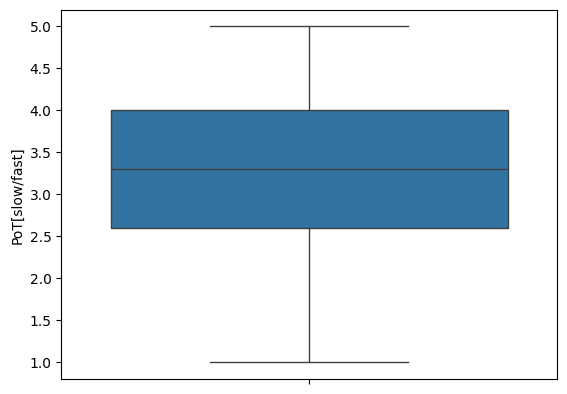

In [20]:
#check distribution after outliers removal
sns.boxplot(df["PoT[slow/fast]"])

In [21]:
#STEP3 - analysis
# 
# correlations general - tested both with and without outliers, using either df_test_outliersIQR or simple df. no difference, neither showed a signf corr for relative estimates. Go without excluding outliers then.

linear_variables = ["PoT[slow/fast]", "relative_estimate", "difficulty[easy/difficult]", "engagementEmotional[boring/interesting]", "familiarity[unfamiliar/familiar]", "FA", "ED", "MW", "MB", "TRI"]

with open ("analysis.txt", "a")as analysis:
    analysis.write("Significant correlations /n")
    for a in linear_variables:
        for b in linear_variables:
            r, p = stats.pearsonr(df[a], df[b])
            if b > a:
                if p < 0.05:   
                    if r > 0.20 or r < -0.20:
                        result = (a," x ", b,", pearson r = ", r, ", p value = ", p)
                        result_str = "".join([str(s) for s in result])
                        print(result_str)
                        analysis.write(result_str)


PoT[slow/fast] x difficulty[easy/difficult], pearson r = -0.22476348653787426, p value = 0.00016176733220117312
PoT[slow/fast] x engagementEmotional[boring/interesting], pearson r = 0.35833745665788924, p value = 8.142353181449456e-10
difficulty[easy/difficult] x engagementEmotional[boring/interesting], pearson r = -0.2579470707866892, p value = 1.3771309715118427e-05
difficulty[easy/difficult] x familiarity[unfamiliar/familiar], pearson r = -0.48393940602248536, p value = 1.1433317347726394e-17
FA x PoT[slow/fast], pearson r = 0.20314346802725342, p value = 0.0006708465293795822
FA x difficulty[easy/difficult], pearson r = -0.28181143052117846, p value = 1.8790676808561572e-06
FA x engagementEmotional[boring/interesting], pearson r = 0.37663589930538693, p value = 9.152911372568681e-11
FA x MW, pearson r = -0.47241416713882933, p value = 8.3500104989109e-17
FA x MB, pearson r = -0.2991039230002799, p value = 3.933269010918973e-07
FA x TRI, pearson r = -0.4454874795523043, p value = 6.

                         Mixed Linear Model Regression Results
Model:                     MixedLM        Dependent Variable:        Q("PoT[slow/fast]")
No. Observations:          277            Method:                    REML               
No. Groups:                49             Scale:                     0.6509             
Min. group size:           3              Log-Likelihood:            -355.1481          
Max. group size:           6              Converged:                 Yes                
Mean group size:           5.7                                                          
----------------------------------------------------------------------------------------
                                              Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------------------------------
Intercept                                      3.691    0.132 27.917 0.000  3.432  3.950
Q("Group-Solo")[T.Solo]                       -

/opt/miniconda3/envs/audioenv/lib/python3.11/site-packages/statsmodels/base/model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(
/var/folders/df/24q1vg6s2dd3v6ttwc3nn0qw0000gn/T/ipykernel_38510/2188367200.py:30: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  chi2 = float(wald.statistic)


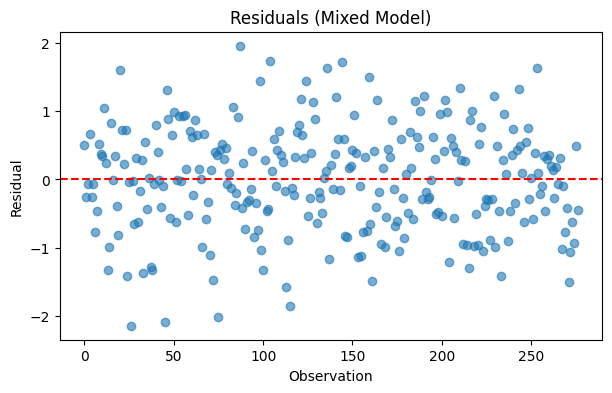

Statistic: 0.9963086306913093, P-Value: 0.7663327344082532


In [22]:
# Linear Mixed Model -- PoT  ------ USE THIS ONE AS MAIN, 

md_pot = smf.mixedlm(
    'Q("PoT[slow/fast]") ~ Q("Group-Solo") * Q("Type-improv")',
    data=df,
    groups=df["ID de participante"],
    
)
results = md_pot.fit()

print(results.summary())


# --- Get parameter names
param_names = results.params.index.tolist()
print("Parameters:", param_names)

# --- function to compute Wald omnibus test
def omnibus_wald(results, param_names):
    # Get indices of the exact parameters
    idx = [results.params.index.get_loc(name) for name in param_names]

    # Build restriction matrix
    R = np.zeros((len(idx), len(results.params)))
    for i, j in enumerate(idx):
        R[i, j] = 1

    # Wald test
    wald = results.wald_test(R)
    chi2 = float(wald.statistic)
    df_num = len(idx)
    df_den = results.df_resid  # still approximate!
    F = chi2 / df_num
    p_F = 1 - stats.f.cdf(F, df_num, df_den)

    return chi2, df_num, df_den, F, p_F

# --- Define parameter groups explicitly

group_params = [
    'Q("Group-Solo")[T.Solo]'
]

type_params = [
    'Q("Type-improv")[T.A]',
    'Q("Type-improv")[T.B]'
]

interaction_params = [
    'Q("Group-Solo")[T.Solo]:Q("Type-improv")[T.A]',
    'Q("Group-Solo")[T.Solo]:Q("Type-improv")[T.B]'
]

# --- Run omnibus tests
chi2_group, df1_g, df2_g, F_g, p_g = omnibus_wald(results, group_params)
chi2_type,  df1_t, df2_t, F_t, p_t = omnibus_wald(results, type_params)
chi2_int,   df1_i, df2_i, F_i, p_i = omnibus_wald(results, interaction_params)
# --- Print results
print(f"Group: χ²({df1_g}) = {chi2_group:.2f}, F({df1_g}, {df2_g:.0f}) = {F_g:.2f}, p = {p_g:.4f}")
print(f"Type:  χ²({df1_t}) = {chi2_type:.2f}, F({df1_t}, {df2_t:.0f}) = {F_t:.2f}, p = {p_t:.4f}")
print(f"Interaction: χ²({df1_i}) = {chi2_int:.2f}, F({df1_i}, {df2_i:.0f}) = {F_i:.2f}, p = {p_i:.4f}")

# residuals for mixed models and prediction vs real values, generate plots

resid = results.resid

plt.figure(figsize=(7,4))
plt.plot(np.arange(len(resid)), resid, marker="o", linestyle="", alpha=0.6)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Observation")
plt.ylabel("Residual")
plt.title("Residuals (Mixed Model)")
plt.show()

# Perform Shapiro-Wilk Test
statistic, p_value = shapiro(resid)

print(f'Statistic: {statistic}, P-Value: {p_value}')




                         Mixed Linear Model Regression Results
Model:                     MixedLM        Dependent Variable:        Q("PoT[slow/fast]")
No. Observations:          277            Method:                    REML               
No. Groups:                49             Scale:                     0.5251             
Min. group size:           3              Log-Likelihood:            -335.3429          
Max. group size:           6              Converged:                 Yes                
Mean group size:           5.7                                                          
----------------------------------------------------------------------------------------
                                              Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------------------------------
Intercept                                      2.514    0.312  8.061 0.000  1.903  3.125
Q("Group-Solo")[T.Solo]                       -

/opt/miniconda3/envs/audioenv/lib/python3.11/site-packages/statsmodels/base/model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(
/var/folders/df/24q1vg6s2dd3v6ttwc3nn0qw0000gn/T/ipykernel_38510/414537764.py:31: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  chi2 = float(wald.statistic)


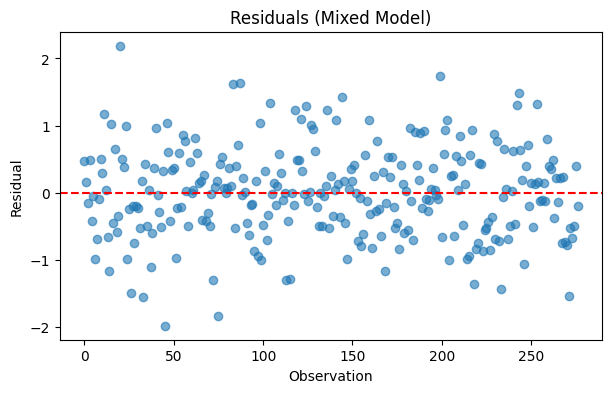

Statistic: 0.99741356139844, P-Value: 0.9404538905808051


In [23]:
# model PoT with group, improv type + covariates: enjoyment and possible consciousness states


md_pot = smf.mixedlm(
    'Q("PoT[slow/fast]") ~ Q("Group-Solo") * Q("Type-improv") + Q("engagementEmotional[boring/interesting]") + Q("MW")',
    data=df,
    groups=df["ID de participante"],
    
)
results = md_pot.fit()

print(results.summary())


# --- Get parameter names
param_names = results.params.index.tolist()
print("Parameters:", param_names)

# --- function to compute Wald omnibus test
def omnibus_wald(results, param_names):
    # Get indices of the exact parameters
    idx = [results.params.index.get_loc(name) for name in param_names]

    # Build restriction matrix
    R = np.zeros((len(idx), len(results.params)))
    for i, j in enumerate(idx):
        R[i, j] = 1

    # Wald test
    wald = results.wald_test(R)
    chi2 = float(wald.statistic)
    df_num = len(idx)
    df_den = results.df_resid  # still approximate!
    F = chi2 / df_num
    p_F = 1 - stats.f.cdf(F, df_num, df_den)

    return chi2, df_num, df_den, F, p_F

# --- Define parameter groups explicitly

group_params = [
    'Q("Group-Solo")[T.Solo]'
]

type_params = [
    'Q("Type-improv")[T.A]',
    'Q("Type-improv")[T.B]'
]

interaction_params = [
    'Q("Group-Solo")[T.Solo]:Q("Type-improv")[T.A]',
    'Q("Group-Solo")[T.Solo]:Q("Type-improv")[T.B]'
]

# --- Run omnibus tests
chi2_group, df1_g, df2_g, F_g, p_g = omnibus_wald(results, group_params)
chi2_type,  df1_t, df2_t, F_t, p_t = omnibus_wald(results, type_params)
#chi2_type,  df1_t, df2_t, F_t, p_t = omnibus_wald(results, Q(""))
#chi2_type,  df1_t, df2_t, F_t, p_t = omnibus_wald(results, type_params)
chi2_int,   df1_i, df2_i, F_i, p_i = omnibus_wald(results, interaction_params)
# --- Print results
print(f"Group: χ²({df1_g}) = {chi2_group:.2f}, F({df1_g}, {df2_g:.0f}) = {F_g:.2f}, p = {p_g:.4f}")
print(f"Type:  χ²({df1_t}) = {chi2_type:.2f}, F({df1_t}, {df2_t:.0f}) = {F_t:.2f}, p = {p_t:.4f}")
print(f"Interaction: χ²({df1_i}) = {chi2_int:.2f}, F({df1_i}, {df2_i:.0f}) = {F_i:.2f}, p = {p_i:.4f}")

# residuals for mixed models and prediction vs real values, generate plots

resid = results.resid

plt.figure(figsize=(7,4))
plt.plot(np.arange(len(resid)), resid, marker="o", linestyle="", alpha=0.6)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Observation")
plt.ylabel("Residual")
plt.title("Residuals (Mixed Model)")
plt.show()

# Perform Shapiro-Wilk Test
statistic, p_value = shapiro(resid)

print(f'Statistic: {statistic}, P-Value: {p_value}')

                          Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Q("engagementEmotional[boring/interesting]")
No. Observations: 277     Method:             REML                                        
No. Groups:       49      Scale:              0.6628                                      
Min. group size:  3       Log-Likelihood:     -357.5376                                   
Max. group size:  6       Converged:          Yes                                         
Mean group size:  5.7                                                                     
------------------------------------------------------------------------------------------
                                                Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------------------------------
Intercept                                        4.316    0.133 32.358 0.000  4.054  4.577
Q("Group-Solo")[T.Solo]   

/opt/miniconda3/envs/audioenv/lib/python3.11/site-packages/statsmodels/base/model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(
/var/folders/df/24q1vg6s2dd3v6ttwc3nn0qw0000gn/T/ipykernel_38510/4150460703.py:31: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  chi2 = float(wald.statistic)


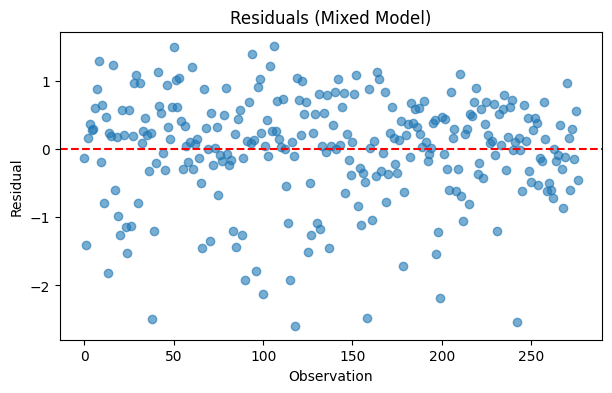

Statistic: 0.945131894387147, P-Value: 1.174457041749238e-08
                                           GEE Regression Results                                          
Dep. Variable:        Q("engagementEmotional[boring/interesting]")   No. Observations:                  277
Model:                                                         GEE   No. clusters:                       49
Method:                                                Generalized   Min. cluster size:                   3
                                              Estimating Equations   Max. cluster size:                   6
Family:                                                   Gaussian   Mean cluster size:                 5.7
Dependence structure:                                 Independence   Num. iterations:                     2
Date:                                             Wed, 01 Jul 2026   Scale:                           0.789
Covariance type:                                            robust   Time: 

In [24]:
# results suggest emotional engagement is the main predictor of PoT, and different improvisation tasks may lead to different levels of emotional engagement, so let's put emotional engagement as the dependent


md_pot = smf.mixedlm(
    'Q("engagementEmotional[boring/interesting]") ~ Q("Group-Solo") * Q("Type-improv")',
    data=df,
    groups=df["ID de participante"],
    
)
results = md_pot.fit()

print(results.summary())


# --- Get parameter names
param_names = results.params.index.tolist()
print("Parameters:", param_names)

# --- function to compute Wald omnibus test
def omnibus_wald(results, param_names):
    # Get indices of the exact parameters
    idx = [results.params.index.get_loc(name) for name in param_names]

    # Build restriction matrix
    R = np.zeros((len(idx), len(results.params)))
    for i, j in enumerate(idx):
        R[i, j] = 1

    # Wald test
    wald = results.wald_test(R)
    chi2 = float(wald.statistic)
    df_num = len(idx)
    df_den = results.df_resid  # still approximate!
    F = chi2 / df_num
    p_F = 1 - stats.f.cdf(F, df_num, df_den)

    return chi2, df_num, df_den, F, p_F

# --- Define parameter groups explicitly

group_params = [
    'Q("Group-Solo")[T.Solo]'
]

type_params = [
    'Q("Type-improv")[T.A]',
    'Q("Type-improv")[T.B]'
]

interaction_params = [
    'Q("Group-Solo")[T.Solo]:Q("Type-improv")[T.A]',
    'Q("Group-Solo")[T.Solo]:Q("Type-improv")[T.B]'
]

# --- Run omnibus tests
chi2_group, df1_g, df2_g, F_g, p_g = omnibus_wald(results, group_params)
chi2_type,  df1_t, df2_t, F_t, p_t = omnibus_wald(results, type_params)
#chi2_type,  df1_t, df2_t, F_t, p_t = omnibus_wald(results, Q(""))
#chi2_type,  df1_t, df2_t, F_t, p_t = omnibus_wald(results, type_params)
chi2_int,   df1_i, df2_i, F_i, p_i = omnibus_wald(results, interaction_params)
# --- Print results
print(f"Group: χ²({df1_g}) = {chi2_group:.2f}, F({df1_g}, {df2_g:.0f}) = {F_g:.2f}, p = {p_g:.4f}")
print(f"Type:  χ²({df1_t}) = {chi2_type:.2f}, F({df1_t}, {df2_t:.0f}) = {F_t:.2f}, p = {p_t:.4f}")
print(f"Interaction: χ²({df1_i}) = {chi2_int:.2f}, F({df1_i}, {df2_i:.0f}) = {F_i:.2f}, p = {p_i:.4f}")

# residuals for mixed models and prediction vs real values, generate plots

resid = results.resid

plt.figure(figsize=(7,4))
plt.plot(np.arange(len(resid)), resid, marker="o", linestyle="", alpha=0.6)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Observation")
plt.ylabel("Residual")
plt.title("Residuals (Mixed Model)")
plt.show()

# Perform Shapiro-Wilk Test
statistic, p_value = shapiro(resid)

print(f'Statistic: {statistic}, P-Value: {p_value}')


# residuals not normal, and intermediate analysis with sqrt did not solve that. So confirm with gee.

gee_eng = smf.gee(
    'Q("engagementEmotional[boring/interesting]") ~ Q("Type-improv") * Q("Group-Solo")',
    groups="ID de participante",
    data=df,
    family=sm.families.Gaussian()
)

gee_results = gee_eng.fit()
print(gee_results.summary())

Rows kept: 265
                         Mixed Linear Model Regression Results
Model:                 MixedLM      Dependent Variable:      Q("relative_estimate_sqrt")
No. Observations:      265          Method:                  REML                       
No. Groups:            48           Scale:                   0.0172                     
Min. group size:       2            Log-Likelihood:          107.9431                   
Max. group size:       6            Converged:               Yes                        
Mean group size:       5.5                                                              
----------------------------------------------------------------------------------------
                                              Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------------------------------
Intercept                                      1.162    0.027 43.542 0.000  1.110  1.214
Q("Group-Solo")[T.Solo]         

/opt/miniconda3/envs/audioenv/lib/python3.11/site-packages/statsmodels/base/model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(
/var/folders/df/24q1vg6s2dd3v6ttwc3nn0qw0000gn/T/ipykernel_38510/3230387316.py:49: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  chi2 = float(wald.statistic)


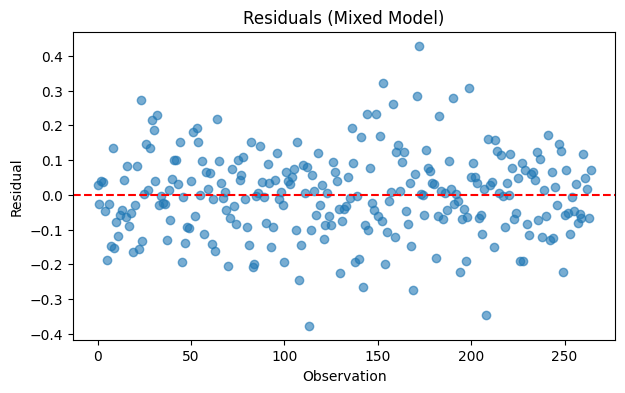

Statistic: 0.9946929588729784, P-Value: 0.48780085138254753


In [25]:
#model on duration estimates, remove outliers first! TESTED POSSIBLE COVARIATES - DIFFICULTY, FAMILIARITY; F.A. and OTHERS - none was significant!!!

# --- outliers ----


df_test_outliersIQR = df.copy()

q1 = df_test_outliersIQR["relative_estimate"].quantile(0.25)
q3 = df_test_outliersIQR["relative_estimate"].quantile(0.75)
IQR = q3 - q1

lower = q1 - 1.5 * IQR
upper = q3 + 1.5 * IQR

df_test_outliersIQR = df_test_outliersIQR[
    (df_test_outliersIQR["relative_estimate"] >= lower) &
    (df_test_outliersIQR["relative_estimate"] <= upper)
]

print("Rows kept:", len(df_test_outliersIQR))

# previous inspection showed sqrt is needed to achieve normal resid distribution. 

df_test_outliersIQR["relative_estimate_sqrt"] = np.sqrt(df_test_outliersIQR["relative_estimate"])

md = smf.mixedlm(
    'Q("relative_estimate_sqrt") ~ Q("Group-Solo") * Q("Type-improv")',
    data=(df_test_outliersIQR),
    groups=df_test_outliersIQR["ID de participante"]
)

results = md.fit()

print(results.summary())


# --- function to compute Wald omnibus test
def omnibus_wald(results, param_names):
    # Get indices of the exact parameters
    idx = [results.params.index.get_loc(name) for name in param_names]

    # Build restriction matrix
    R = np.zeros((len(idx), len(results.params)))
    for i, j in enumerate(idx):
        R[i, j] = 1

    # Wald test
    wald = results.wald_test(R)
    chi2 = float(wald.statistic)
    df_num = len(idx)
    df_den = results.df_resid  # still approximate!
    F = chi2 / df_num
    p_F = 1 - stats.f.cdf(F, df_num, df_den)

    return chi2, df_num, df_den, F, p_F

# --- Define parameter groups explicitly

group_params = [
    'Q("Group-Solo")[T.Solo]'
]

type_params = [
    'Q("Type-improv")[T.A]',
    'Q("Type-improv")[T.B]'
]

interaction_params = [
    'Q("Group-Solo")[T.Solo]:Q("Type-improv")[T.A]',
    'Q("Group-Solo")[T.Solo]:Q("Type-improv")[T.B]'
]

# --- Run omnibus tests
chi2_group, df1_g, df2_g, F_g, p_g = omnibus_wald(results, group_params)
chi2_type,  df1_t, df2_t, F_t, p_t = omnibus_wald(results, type_params)
#chi2_type,  df1_t, df2_t, F_t, p_t = omnibus_wald(results, Q(""))
#chi2_type,  df1_t, df2_t, F_t, p_t = omnibus_wald(results, type_params)
chi2_int,   df1_i, df2_i, F_i, p_i = omnibus_wald(results, interaction_params)
# --- Print results
print(f"Group: χ²({df1_g}) = {chi2_group:.2f}, F({df1_g}, {df2_g:.0f}) = {F_g:.2f}, p = {p_g:.4f}")
print(f"Type:  χ²({df1_t}) = {chi2_type:.2f}, F({df1_t}, {df2_t:.0f}) = {F_t:.2f}, p = {p_t:.4f}")
print(f"Interaction: χ²({df1_i}) = {chi2_int:.2f}, F({df1_i}, {df2_i:.0f}) = {F_i:.2f}, p = {p_i:.4f}")

# residuals for mixed models and prediction vs real values, generate plots

resid = results.resid

plt.figure(figsize=(7,4))
plt.plot(np.arange(len(resid)), resid, marker="o", linestyle="", alpha=0.6)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Observation")
plt.ylabel("Residual")
plt.title("Residuals (Mixed Model)")
plt.show()

# Perform Shapiro-Wilk Test
statistic, p_value = shapiro(resid)

print(f'Statistic: {statistic}, P-Value: {p_value}')



In [26]:
# --- DE did not differ according to improvisation task, but according to group/solo. Did FA change in group/solo, or Improv tasks? TEST!!!

#perceived difficulty?
md = smf.mixedlm(
    'Q("difficulty[easy/difficult]") ~ Q("Group-Solo") * Q("Type-improv")',
    data=(df_test_outliersIQR),
    groups=df_test_outliersIQR["ID de participante"]
)

results = md.fit()

print(results.summary())

# --- Get parameter names
param_names = results.params.index.tolist()
print("Parameters:", param_names)

# --- Helper function to compute Wald omnibus test
def omnibus_wald(results, param_names):
    # Get indices of the exact parameters
    idx = [results.params.index.get_loc(name) for name in param_names]

    # Build restriction matrix
    R = np.zeros((len(idx), len(results.params)))
    for i, j in enumerate(idx):
        R[i, j] = 1

    # Wald test
    wald = results.wald_test(R)
    chi2 = float(wald.statistic)
    df_num = len(idx)
    df_den = results.df_resid  # still approximate!
    F = chi2 / df_num
    p_F = 1 - stats.f.cdf(F, df_num, df_den)

    return chi2, df_num, df_den, F, p_F

# --- Run omnibus tests for each predictor
chi2_group, df1_g, df2_g, F_g, p_g = omnibus_wald(results, "Group-Solo")
chi2_type,  df1_t, df2_t, F_t, p_t = omnibus_wald(results, "Type-improv")
chi2_int, df1_i, df2_i, F_i, p_i = omnibus_wald(results, ':')

# --- Print results
print(f"Group: χ²({df1_g}) = {chi2_group:.2f}, F({df1_g}, {df2_g:.0f}) = {F_g:.2f}, p = {p_g:.4f}")
print(f"Type:  χ²({df1_t}) = {chi2_type:.2f}, F({df1_t}, {df2_t:.0f}) = {F_t:.2f}, p = {p_t:.4f}")
print(f"Interaction: χ²({df1_i}) = {chi2_int:.2f}, F({df1_i}, {df2_i:.0f}) = {F_i:.2f}, p = {p_i:.4f}")

# residuals for mixed models and prediction vs real values, generate plots

resid = results.resid

plt.figure(figsize=(7,4))
plt.plot(np.arange(len(resid)), resid, marker="o", linestyle="", alpha=0.6)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Observation")
plt.ylabel("Residual")
plt.title("Residuals (Mixed Model)")
plt.show()

# Perform Shapiro-Wilk Test
statistic, p_value = shapiro(resid)

df_free= df[
    (df["Type-improv"] == "Free")
]
df_familiar= df[
    (df["Type-improv"] == "Structured_familiar")
]
df_unfamiliar= df[
    (df["Type-improv"] == "Structured_unfamiliar")
]

mean_free = np.mean(df_free["difficulty[easy/difficult]"])
std_free = np.std(df_free["difficulty[easy/difficult]"])
mean_familiar = np.mean(df_familiar["difficulty[easy/difficult]"])
std_familiar = np.std(df_familiar["difficulty[easy/difficult]"])
mean_unfamiliar = np.mean(df_unfamiliar["difficulty[easy/difficult]"])
std_unfamiliar = np.std(df_unfamiliar["difficulty[easy/difficult]"])
print(f'Statistic: {statistic}, P-Value: {p_value}')
print(f"means of perceived difficulty: free M = {mean_free} familiar M = {mean_familiar} unfamiliar M = {mean_unfamiliar}")
print(f"std of perceived difficulty: free M = {std_free} familiar M = {std_familiar} unfamiliar M = {std_unfamiliar}")


                         Mixed Linear Model Regression Results
Model:                 MixedLM    Dependent Variable:    Q("difficulty[easy/difficult]")
No. Observations:      265        Method:                REML                           
No. Groups:            48         Scale:                 0.8085                         
Min. group size:       2          Log-Likelihood:        -371.0677                      
Max. group size:       6          Converged:             Yes                            
Mean group size:       5.5                                                              
----------------------------------------------------------------------------------------
                                              Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------------------------------
Intercept                                      2.560    0.154 16.644 0.000  2.258  2.861
Q("Group-Solo")[T.Solo]                       -

KeyError: 'G'

In [ ]:
#   ------------------------------------------------ role of INSTRUMENTS on time perception

                     Mixed Linear Model Regression Results
Model:              MixedLM   Dependent Variable:   Q("relative_estimate_sqrt")
No. Observations:   264       Method:               REML                       
No. Groups:         48        Scale:                0.0179                     
Min. group size:    2         Log-Likelihood:       107.7910                   
Max. group size:    6         Converged:            Yes                        
Mean group size:    5.5                                                        
-------------------------------------------------------------------------------
                                      Coef. Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------------------------
Intercept                             1.114    0.055 20.100 0.000  1.005  1.222
Q("Tipo de instrumento ")[T.Drum]     0.037    0.070  0.530 0.596 -0.100  0.175
Q("Tipo de instrumento ")[T.Harmonic] 0.101    0.067  1.507 0

/opt/miniconda3/envs/audioenv/lib/python3.11/site-packages/statsmodels/base/model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(
/var/folders/df/24q1vg6s2dd3v6ttwc3nn0qw0000gn/T/ipykernel_12845/4233849687.py:34: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  chi2 = float(wald.statistic)


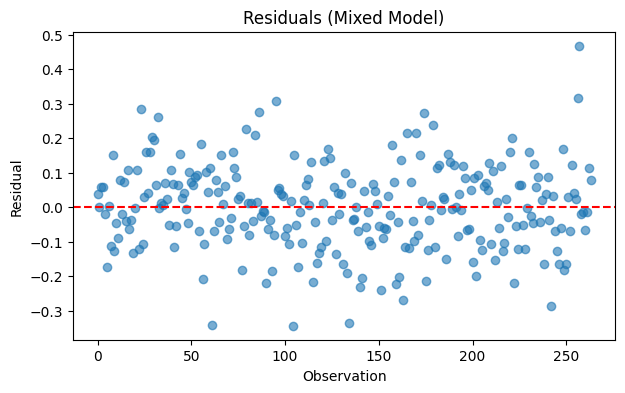

Statistic: 0.9944217914408332, P-Value: 0.4447043710042686


In [ ]:
#----- INSTRUMENTS and DE


df_test_outliersIQR["relative_estimate_sqrt"] = np.sqrt(df_test_outliersIQR["relative_estimate"])

md = smf.mixedlm(
    'Q("relative_estimate_sqrt") ~ Q("Tipo de instrumento ")',
    data=(df_test_outliersIQR),
    groups=df_test_outliersIQR["ID de participante"]
)

results = md.fit()

print(results.summary())

# --- Get parameter names
param_names = results.params.index.tolist()
print("Parameters:", param_names)

# --- Helper function to compute Wald omnibus test
def omnibus_wald(results, param_names):
    # Get indices of the exact parameters
    idx = [results.params.index.get_loc(name) for name in param_names]

    # Build restriction matrix
    R = np.zeros((len(idx), len(results.params)))
    for i, j in enumerate(idx):
        R[i, j] = 1

    # Wald test
    wald = results.wald_test(R)
    chi2 = float(wald.statistic)
    df_num = len(idx)
    df_den = results.df_resid  # still approximate!
    F = chi2 / df_num
    p_F = 1 - stats.f.cdf(F, df_num, df_den)

    return chi2, df_num, df_den, F, p_F

# --- Run omnibus tests for each predictor
chi2_group, df1_g, df2_g, F_g, p_g = omnibus_wald(results, "Tipo de instrumento")


# --- Print results
print(f"Group: χ²({df1_g}) = {chi2_group:.2f}, F({df1_g}, {df2_g:.0f}) = {F_g:.2f}, p = {p_g:.4f}")

# residuals for mixed models and prediction vs real values, generate plots

resid = results.resid

plt.figure(figsize=(7,4))
plt.plot(np.arange(len(resid)), resid, marker="o", linestyle="", alpha=0.6)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Observation")
plt.ylabel("Residual")
plt.title("Residuals (Mixed Model)")
plt.show()

# Perform Shapiro-Wilk Test
statistic, p_value = shapiro(resid)

print(f'Statistic: {statistic}, P-Value: {p_value}')

                                       Mixed Linear Model Regression Results
Model:                              MixedLM                 Dependent Variable:                 Q("PoT[slow/fast]")
No. Observations:                   275                     Method:                             REML               
No. Groups:                         49                      Scale:                              0.6950             
Min. group size:                    3                       Log-Likelihood:                     -355.8040          
Max. group size:                    6                       Converged:                          Yes                
Mean group size:                    5.6                                                                            
-------------------------------------------------------------------------------------------------------------------
                                                                         Coef.  Std.Err.   z    P>|z| [0.025 0.

/opt/miniconda3/envs/audioenv/lib/python3.11/site-packages/statsmodels/base/model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(
/var/folders/df/24q1vg6s2dd3v6ttwc3nn0qw0000gn/T/ipykernel_12845/3855773490.py:31: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  chi2 = float(wald.statistic)


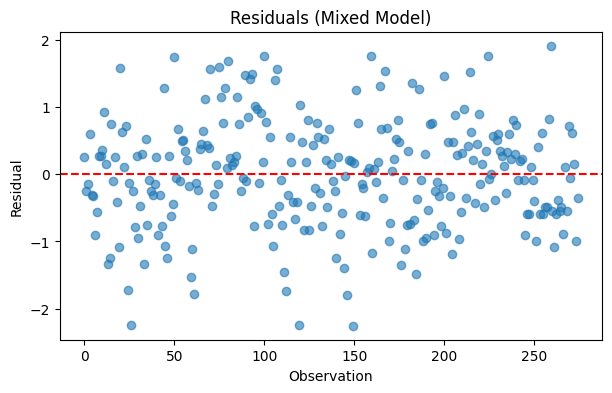

Statistic: 0.9935281574785223, P-Value: 0.28404037553651995


<Axes: xlabel='Tipo de instrumento ', ylabel='PoT[slow/fast]'>

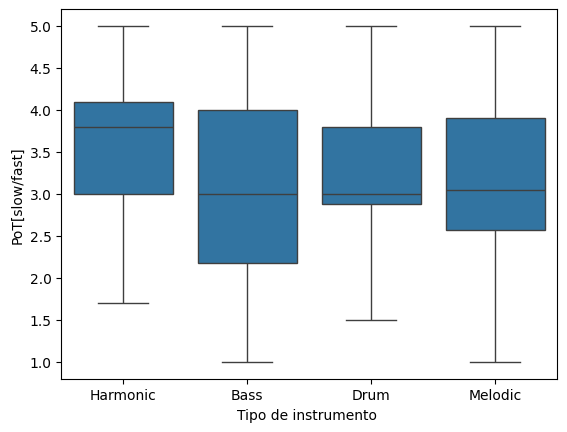

In [ ]:
# --- INSTRUMENTS and PoT

md = smf.mixedlm(
    'Q("PoT[slow/fast]") ~ C(Q("Tipo de instrumento "), Treatment(reference="Harmonic"))',
    data=(df),
    groups=df["ID de participante"]
)

results = md.fit()

print(results.summary())

# --- Get parameter names
param_names = results.params.index.tolist()
print("Parameters:", param_names)

# --- Helper function to compute Wald omnibus test
def omnibus_wald(results, param_names):
    # Get indices of the exact parameters
    idx = [results.params.index.get_loc(name) for name in param_names]

    # Build restriction matrix
    R = np.zeros((len(idx), len(results.params)))
    for i, j in enumerate(idx):
        R[i, j] = 1

    # Wald test
    wald = results.wald_test(R)
    chi2 = float(wald.statistic)
    df_num = len(idx)
    df_den = results.df_resid  # still approximate!
    F = chi2 / df_num
    p_F = 1 - stats.f.cdf(F, df_num, df_den)

    return chi2, df_num, df_den, F, p_F

# --- Run omnibus tests for each predictor
chi2_group, df1_g, df2_g, F_g, p_g = omnibus_wald(results, "Tipo de instrumento")


# --- Print results
print(f"Group: χ²({df1_g}) = {chi2_group:.2f}, F({df1_g}, {df2_g:.0f}) = {F_g:.2f}, p = {p_g:.4f}")

# residuals for mixed models and prediction vs real values, generate plots

resid = results.resid

plt.figure(figsize=(7,4))
plt.plot(np.arange(len(resid)), resid, marker="o", linestyle="", alpha=0.6)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Observation")
plt.ylabel("Residual")
plt.title("Residuals (Mixed Model)")
plt.show()

# Perform Shapiro-Wilk Test
statistic, p_value = shapiro(resid)

print(f'Statistic: {statistic}, P-Value: {p_value}')

sns.boxplot (x = "Tipo de instrumento ", y = "PoT[slow/fast]", data=df)

                                       Mixed Linear Model Regression Results
Model:                     MixedLM         Dependent Variable:         Q("engagementEmotional[boring/interesting]")
No. Observations:          275             Method:                     REML                                        
No. Groups:                49              Scale:                      0.7810                                      
Min. group size:           3               Log-Likelihood:             -371.7565                                   
Max. group size:           6               Converged:                  Yes                                         
Mean group size:           5.6                                                                                     
-------------------------------------------------------------------------------------------------------------------
                                                                         Coef.  Std.Err.   z    P>|z| [0.025 0.

/opt/miniconda3/envs/audioenv/lib/python3.11/site-packages/statsmodels/base/model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(
/var/folders/df/24q1vg6s2dd3v6ttwc3nn0qw0000gn/T/ipykernel_12845/2231824215.py:28: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  chi2 = float(wald.statistic)


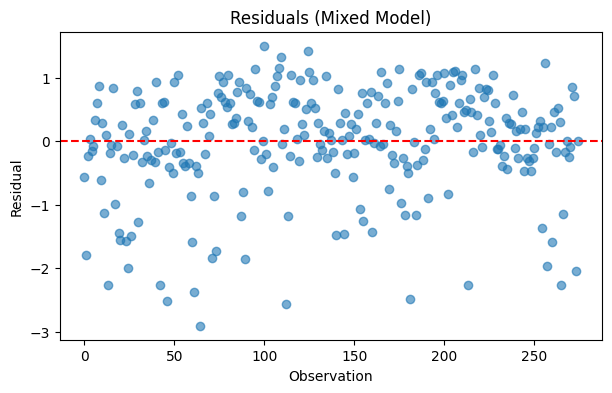

Statistic: 0.924433318338444, P-Value: 1.3475399461235236e-10
                                           GEE Regression Results                                          
Dep. Variable:        Q("engagementEmotional[boring/interesting]")   No. Observations:                  275
Model:                                                         GEE   No. clusters:                       49
Method:                                                Generalized   Min. cluster size:                   3
                                              Estimating Equations   Max. cluster size:                   6
Family:                                                   Gaussian   Mean cluster size:                 5.6
Dependence structure:                                 Independence   Num. iterations:                     2
Date:                                             Thu, 16 Apr 2026   Scale:                           0.878
Covariance type:                                            robust   Time:

In [ ]:
# LMM for Path a: Type-instrument → Emotional engagement, to see if it explains PoT differences
md_eng = smf.mixedlm(
    'Q("engagementEmotional[boring/interesting]") ~ C(Q("Tipo de instrumento "), Treatment(reference="Harmonic"))',
    data=df,
    groups=df["ID de participante"]
)
results_eng = md_eng.fit()
print(results_eng.summary())

# --- Get parameter names
param_names = results_eng.params.index.tolist()
print("Parameters:", param_names)

# --- Helper function to compute Wald omnibus test
def omnibus_wald(results, param_names):
    # Get indices of the exact parameters
    idx = [results.params.index.get_loc(name) for name in param_names]

    # Build restriction matrix
    R = np.zeros((len(idx), len(results.params)))
    for i, j in enumerate(idx):
        R[i, j] = 1

    # Wald test
    wald = results.wald_test(R)
    chi2 = float(wald.statistic)
    df_num = len(idx)
    df_den = results.df_resid  # still approximate!
    F = chi2 / df_num
    p_F = 1 - stats.f.cdf(F, df_num, df_den)

    return chi2, df_num, df_den, F, p_F

# --- Run omnibus tests for each predictor
chi2_group, df1_g, df2_g, F_g, p_g = omnibus_wald(results_eng, "Tipo de instrumento ")

# --- Print results
print(f"Group: χ²({df1_g}) = {chi2_group:.2f}, F({df1_g}, {df2_g:.0f}) = {F_g:.2f}, p = {p_g:.4f}")
print(f"Type:  χ²({df1_t}) = {chi2_type:.2f}, F({df1_t}, {df2_t:.0f}) = {F_t:.2f}, p = {p_t:.4f}")
print(f"Interaction: χ²({df1_i}) = {chi2_int:.2f}, F({df1_i}, {df2_i:.0f}) = {F_i:.2f}, p = {p_i:.4f}")

# residuals for mixed models and prediction vs real values, generate plots

resid = results_eng.resid

plt.figure(figsize=(7,4))
plt.plot(np.arange(len(resid)), resid, marker="o", linestyle="", alpha=0.6)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Observation")
plt.ylabel("Residual")
plt.title("Residuals (Mixed Model)")
plt.show()


# Perform Shapiro-Wilk Test
statistic, p_value = shapiro(resid)

print(f'Statistic: {statistic}, P-Value: {p_value}')

gee_eng = smf.gee(
    'Q("engagementEmotional[boring/interesting]") ~ C(Q("Tipo de instrumento "), Treatment(reference="Harmonic"))',
    groups="ID de participante",
    data=df,
    family=sm.families.Gaussian()
)

gee_results = gee_eng.fit()
print(gee_results.summary())

In [ ]:
# ------ If instruments differ in PoT but not in engagement, check their roles in different musical tasks, confirm if harmonic differ specifically in solo more than in group and in the structured more than in free 

df_solo = df[
    (df["Group-Solo"] == "Solo")
]
df_group = df[
    (df["Group-Solo"] == "Group")
]
df_free = df[
    (df["Type-improv"] == "Free")
]
df_structured = df[
    (df["Type-improv"] != "Free")
]

# Welch ANOVA on a single factor
welch_result = pg.welch_anova(dv="PoT[slow/fast]", between="Tipo de instrumento ", data=df_solo)
print("for solo tasks, significant: \n", welch_result)

welch_result = pg.welch_anova(dv="PoT[slow/fast]", between="Tipo de instrumento ", data=df_group)
print("for group tasks, not: \n", welch_result)

welch_result = pg.welch_anova(dv="PoT[slow/fast]", between="Tipo de instrumento ", data=df_free)
print("for free tasks, not: \n", welch_result)

welch_result = pg.welch_anova(dv="PoT[slow/fast]", between="Tipo de instrumento ", data=df_structured)
print("for structured tasks, relevant: \n", welch_result)


for solo tasks, significant: 
                  Source  ddof1      ddof2         F     p-unc      np2
0  Tipo de instrumento       3  54.771689  6.173741  0.001084  0.09895
for group tasks, not: 
                  Source  ddof1      ddof2         F     p-unc       np2
0  Tipo de instrumento       3  56.684709  0.581731  0.629428  0.013472
for free tasks, not: 
                  Source  ddof1      ddof2         F     p-unc       np2
0  Tipo de instrumento       3  36.367735  0.423541  0.737256  0.013707
for structured tasks, relevant: 
                  Source  ddof1      ddof2         F     p-unc       np2
0  Tipo de instrumento       3  75.056221  4.802555  0.004096  0.070082


Researcher P, in another analysis, confirmed no differences in consciousness states according to instruments.
Maybe differences in PoT among instruments come from the music, to include in the discussion section. A separate computational analysis of the audio was done in the file: "audio analysis.ipynb

In [ ]:
#-------- STEP 4 VISUALIZATION --------

  Group-Solo            Type-improv  PoT[slow/fast]
0      Group                   Free        3.693182
1      Group    Structured_familiar        3.252273
2      Group  Structured_unfamiliar        3.172727
3       Solo                   Free        3.389583
4       Solo    Structured_familiar        3.268750
5       Solo  Structured_unfamiliar        3.000000
                      PoT[slow/fast]          
Group-Solo                     Group      Solo
Type-improv                                   
Free                        3.693182  3.389583
Structured_familiar         3.252273  3.268750
Structured_unfamiliar       3.172727  3.000000


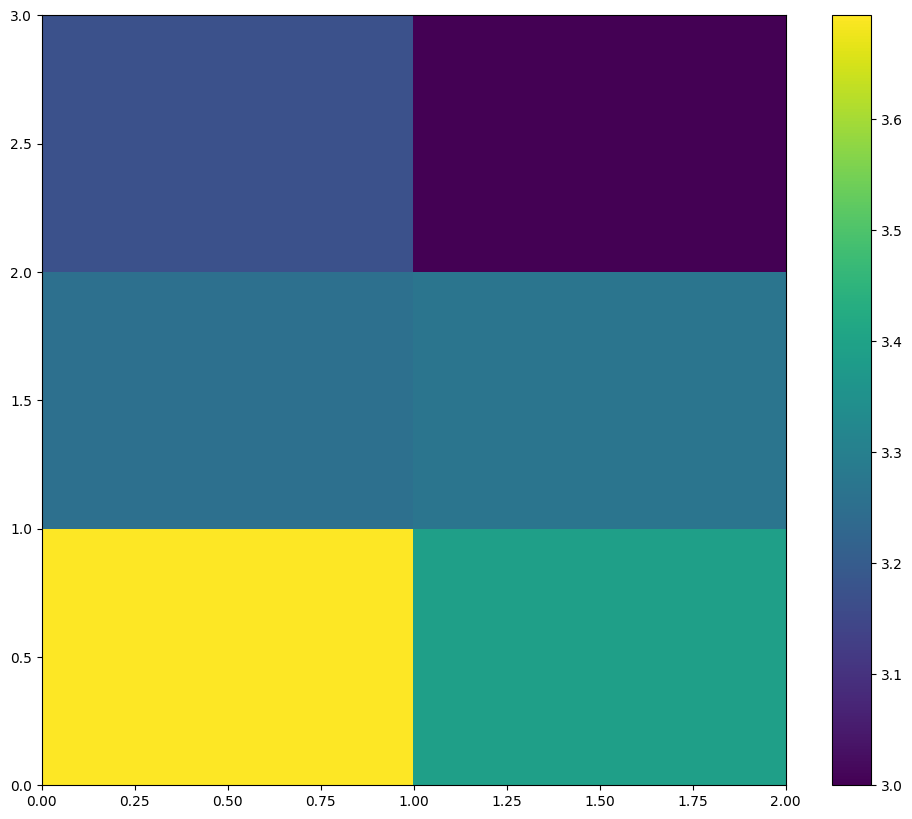

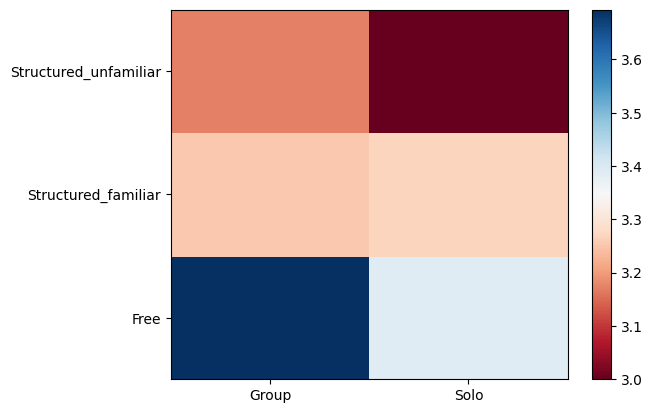

In [ ]:
#-------------------------PLOTS----------------------------------- need to be done each separately, doesn't do them in a series...

# 2 linear variables
#sns.regplot(x= a, y = b, data=df)

# 1 categorical x 1 linear
#sns.boxplot (x = "Type_improv[familiar, unfamiliar, free]", y = "PoT[slow/fast]", data=df)

# 2 categorical x 1 linear

group_work = df[["Group-Solo", "Type-improv", "PoT[slow/fast]"]]
group_paired = group_work.groupby(["Group-Solo", "Type-improv"], as_index=False).mean()
print(group_paired)
group_paired_pivot_table = group_paired.pivot(index= "Type-improv", columns = "Group-Solo")
print(group_paired_pivot_table)

# set window size
width = 12
height = 10
plt.figure(figsize= (width, height))
#plt.title("title")
plt.pcolor(group_paired_pivot_table)
plt.colorbar()
plt.show()

fig, ax = plt.subplots()
im = ax.pcolor(group_paired_pivot_table, cmap='RdBu')

#label names
row_labels = group_paired_pivot_table.columns.levels[1]
col_labels = group_paired_pivot_table.index

#move ticks and labels to the center
ax.set_xticks(np.arange(group_paired_pivot_table.shape[1]) + 0.5, minor=False)
ax.set_yticks(np.arange(group_paired_pivot_table.shape[0]) + 0.5, minor=False)

#insert labels
ax.set_xticklabels(row_labels, minor=False)
ax.set_yticklabels(col_labels, minor=False)

fig.colorbar(im)

<Axes: xlabel='Type-improv', ylabel='PoT[slow/fast]'>

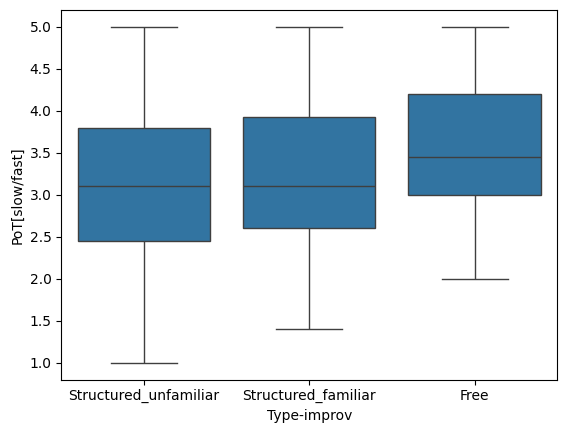

In [ ]:
# 1 categorical x 1 linear
sns.boxplot (x = "Type-improv", y = "PoT[slow/fast]", data=df)

0      1.538462
1      1.538462
2      1.669231
3      1.369231
4      1.058824
         ...   
273    1.475000
274    1.361538
275    1.480000
276    1.808333
277    1.715385
Name: relative_estimate, Length: 264, dtype: float64

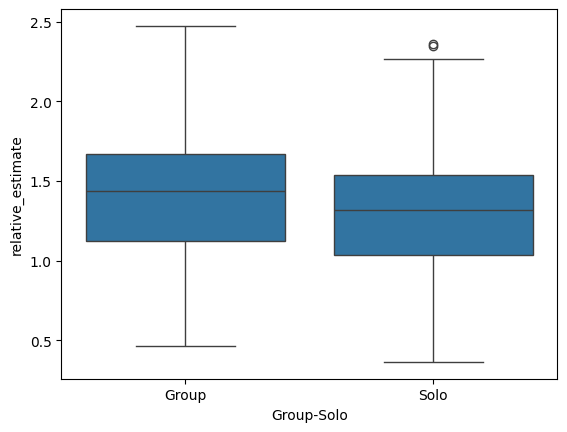

In [ ]:
sns.boxplot (x = "Group-Solo", y = "relative_estimate", data=df_test_outliersIQR)
df_test_outliersIQR["relative_estimate"]